# Tutorial - Extract Gait Features

In [1]:
import sys
import pandas as pd
from typing import Dict, List
from pathlib import Path

project_root = Path.cwd().parent

# Add the project root to the Python path
sys.path.insert(0, str(project_root))
print(f"Project root: {project_root}")

Project root: c:\Users\alexm\dev\alexpose


## 1.  Load GAVD Gait Sequence

In [2]:
from ambient.gavd import GaitDataProcessor, GAVDDataLoader, PoseDataConverter
from ambient.pose.pose_estimators import OpenPoseEstimator
from ambient.utils.csv_parser import parse_csv_with_dicts

2026-01-16 21:49:21.970 | WARNING  | ambient.pose.ultralytics_estimator:<module>:43 - Model utilities not available - using direct model paths


In [3]:
gavd_loader = GAVDDataLoader()
df = gavd_loader.load_gavd_data(Path(project_root, "data", "GAVD_Clinical_Annotations_1.3.csv"))
sequences = gavd_loader.organize_by_sequence(df)
len(sequences)

2026-01-16 21:49:22.610 | INFO     | ambient.gavd.gavd_processor:load_gavd_data:345 - Loading GAVD data from: c:\Users\alexm\dev\alexpose\data\GAVD_Clinical_Annotations_1.3.csv
2026-01-16 21:49:22.615 | WARNING  | ambient.gavd.gavd_processor:_download_youtube_videos:290 - YouTube cookies file not found at c:\Users\alexm\dev\alexpose\config\yt_cookies.txt
2026-01-16 21:49:22.669 | INFO     | ambient.utils.youtube_cache:_prepare_download_list:227 - Already cached (skipping): C:\Users\alexm\dev\alexpose\data\youtube\TgkxrrhnvlM.mp4
2026-01-16 21:49:22.670 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:302 - YouTube cache attempted: 1
2026-01-16 21:49:22.670 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:303 - YouTube cache skipped: 1
2026-01-16 21:49:22.670 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:304 - YouTube cache downloaded: 0
2026-01-16 21:49:22.671 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:308 - Y

1

## 2. Describe Sequence

In [4]:
type(sequences), sequences.keys()

(dict, dict_keys(['cljaoak47000i3n6lsrb9rit9']))

In [5]:
sequence_id = list(sequences.keys())[0]
sequence_data = sequences[sequence_id]
type(sequence_data)

pandas.core.frame.DataFrame

In [6]:
sequence_data.shape

(151, 12)

In [7]:
sequence_data.head(3)

,seq,frame_num,cam_view,gait_event,dataset,gait_pat,bbox,vid_info,id,url,_processed_at,_source_file
0,cljaoak47000i3n6lsrb9rit9,205,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 399.0, 'height': 678.0, '...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-16 21:49:22.673069,unknown
1,cljaoak47000i3n6lsrb9rit9,206,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 380.6666666666667, 'heigh...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-16 21:49:22.673069,unknown
2,cljaoak47000i3n6lsrb9rit9,207,left side,,Abnormal Gait,abnormal,"{'top': 0.0, 'left': 362.3333333333333, 'heigh...","{'height': 720, 'width': 1280, 'mime_type': 'v...",TgkxrrhnvlM,https://www.youtube.com/watch?v=TgkxrrhnvlM,2026-01-16 21:49:22.673069,unknown


## 3. Visualize Frames

Scaled bbox: annotation=1280x720, video=640x360, scale=(0.500, 0.500)
Bbox drawn: left=199, top=0, width=167, height=339


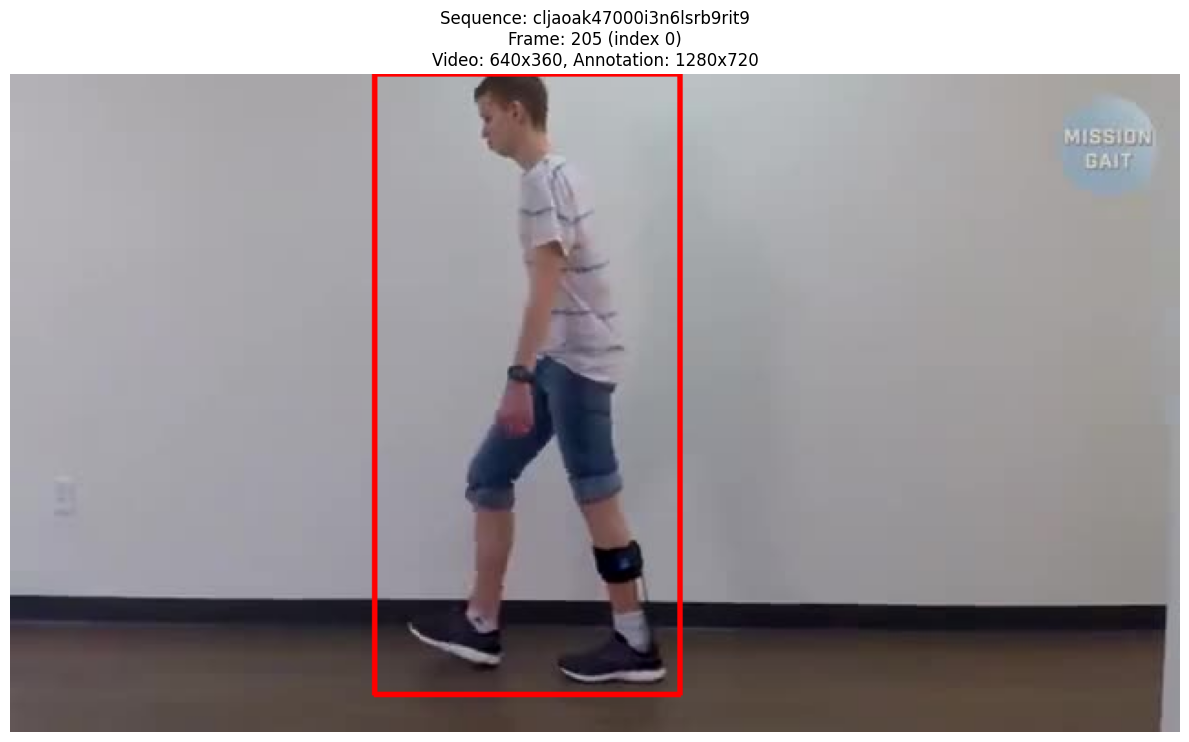

Displayed frame 205 from sequence cljaoak47000i3n6lsrb9rit9


In [8]:
from ambient.utils.viz import visualize_frame

visualize_frame(project_root=project_root, sequences=sequences, seq_id=sequence_id, frame_index=0, show_bbox=True)

## 4. Pose Estimation using MediaPipe

In [9]:
from ambient.pose.keypoints import SequenceKeypointExtractor
from ambient.utils.eval_keypoints import get_gavd_frame, visualize_keypoints

video_base_path = project_root / "data" / "youtube"

extractor = SequenceKeypointExtractor()
keypoints_array = extractor.extract_from_sequence(
    sequence_data,
    video_base_path
)

len(keypoints_array)

[OK] Pose Landmarker created from c:\Users\alexm\dev\alexpose\notebooks\data\models\pose_landmarker_full.task
Processing sequence: cljaoak47000i3n6lsrb9rit9
Number of frames: 151
205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283 284 285 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303 304 305 306 307 308 309 310 311 312 313 314 315 316 317 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333 334 335 336 337 338 339 340 341 342 343 344 345 346 347 348 349 350 351 352 353 354 355 
[OK] Sequence processing complete


151

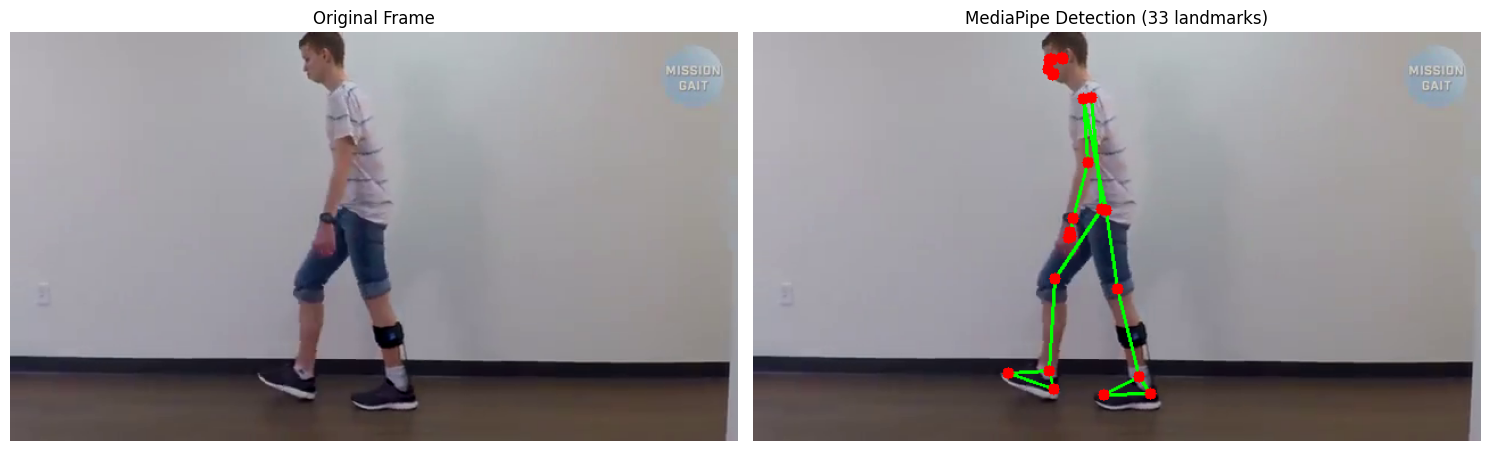

[OK] SUCCESS! Detected 33 landmarks
[INFO] 28 landmarks are visible (confidence > 0.5)
[INFO] Average confidence: 0.850
[INFO] Detection quality: 0.900

[INFO] Sample keypoints:
  NOSE: (259.3, 33.4) confidence=1.000
  LEFT_EYE_INNER: (261.2, 25.7) confidence=1.000
  LEFT_EYE: (262.0, 25.3) confidence=1.000
  LEFT_EYE_OUTER: (263.0, 24.9) confidence=1.000
  RIGHT_EYE_INNER: (260.6, 25.7) confidence=1.000


In [10]:
first_frame = get_gavd_frame(
    sequence_data=sequence_data,
    frame_num=0,
    video_base_path=video_base_path
)
visualize_keypoints(keypoints_array[0], first_frame)